In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
# tf.compat.v1.disable_v2_behavior()
from src.common.utils import get_root_directory,collate_array_elements
import matplotlib.pyplot as plt
from src.preprocessing.data_loader import DataLoader as dl
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import MinMaxScaler
import mlflow
import mlflow.keras
# import keras
# import timeshap

In [7]:
np.random.seed(42)
tf.random.set_seed(42)
lags = 60
n_periods = 7
start_date = "01/01/2021"
end_date = "31/12/2023"
split_size = 0.15

In [8]:
root_dir = get_root_directory()
DL = dl(root_dir)
DL.load_data()
DL.merge_selected_data(selected_data=['BTC','sentiment_analysis'])
DL.final_data.columns

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/2468 [00:00<?, ?it/s]

Index(['ETH_D_AvgPrc', 'ETH_D_PrcDir', 'ETH_YF_Op', 'ETH_YF_Hi', 'ETH_YF_Lo',
       'ETH_YF_Cls', 'ETH_YF_Vol', 'ETH_ES_AvgTransFee', 'ETH_ES_AvgGasPrc',
       'ETH_ES_BlkCnt', 'ETH_ES_BlkSz', 'ETH_ES_BlkTm', 'ETH_ES_ActAdd',
       'ETH_ES_DepCon', 'ETH_ES_GasLmt', 'ETH_ES_GasUsd', 'ETH_ES_VerCon',
       'ETH_OL_MktCap', 'ETH_OL_NewAdd', 'ETH_OL_ChnTrans', 'ETH_OL_ChnVol',
       'BTC_D_AvgPrc', 'BTC_YF_Op', 'BTC_YF_Hi', 'BTC_YF_Lo', 'BTC_YF_Cls',
       'BTC_YF_Vol', 'BTC_OL_MktCap', 'BTC_OL_BlkSz', 'BTC_OL_AvgComPwr',
       'BTC_OL_AvgTransFee', 'BTC_OL_MinDif', 'BTC_OL_ActAdd', 'BTC_OL_NewAdd',
       'BTC_OL_ChnTrans', 'BTC_OL_ChnVol', 'BTC_BIC_HshRt',
       'D_VADER_AvgScr_In', 'D_VADER_Sent_AvgIn', 'D_VADER_AvgScr_Ex',
       'D_VADER_Sent_AvgEx', 'D_FINBERT_AvgScr_In', 'D_FINBERT_Sent_AvgIn',
       'D_FINBERT_AvgScr_Ex', 'D_FINBERT_Sent_AvgEx', 'D_CRYPTOBERT_AvgScr_In',
       'D_CRYPTOBERT_Sent_AvgIn', 'D_CRYPTOBERT_AvgScr_Ex',
       'D_CRYPTOBERT_Sent_AvgEx'],
      dt

In [9]:
features = ['ETH_D_AvgPrc']
DL.select_features(features=features)
DL.set_time_range(start_date=start_date, end_date=end_date)

In [10]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import LearningRateScheduler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, InputLayer, Reshape, Bidirectional, GRU
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses import MeanSquaredError
from tensorflow.keras.metrics import RootMeanSquaredError, MeanSquaredError

In [11]:
model=Sequential()
model.add(InputLayer((lags,len(features))))
# model.add(Bidirectional(LSTM(64, return_sequences=True)))
# model.add(Bidirectional(LSTM(64, return_sequences=True)))
# model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(Bidirectional(LSTM(64, return_sequences=False)))
# model.add(Bidirectional(LSTM(50, return_sequences=False)))
# model.add(Dense(8, "relu"))
model.add(Dense(n_periods))
model.summary()
model.compile(optimizer=Adam(learning_rate=0.01), loss='mse', metrics=[RootMeanSquaredError()])
early_stop = EarlyStopping(monitor='val_loss', restore_best_weights=True, patience=25, verbose=0)

I0000 00:00:1754743352.544572    3425 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13760 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 128)            │        33,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,695 (135.53 KB)

 Trainable params: 34,695 (135.53 KB)

 Non-trainable params: 0 (0.00 B)

In [13]:
split = "val"
train, test = DL.split_data(split_size=split_size)
train, val = DL.split_data(split_size=split_size, split_type="train_val")
y_train, x_train = DL.generate_X_y_tensors(train, data_split="train", lags=lags)
y_val, x_val = DL.generate_X_y_tensors(val, data_split=split, lags=lags)

In [45]:
testss = root_mean_squared_error(y_val[:,1], pd.DataFrame(y_val[:,1].values))

In [48]:
y_scaler,  _ = DL.get_scalers()
afsad = y_scaler.inverse_transform(y_val)

In [49]:
afsad

array([[1884.17874146, 1891.84362793, 1937.06356812, 1945.9664917 ,
        1895.01721191, 1856.53262329, 1847.80966187],
       [1891.84362793, 1937.06356812, 1945.9664917 , 1895.01721191,
        1856.53262329, 1847.80966187, 1843.27102661],
       [1937.06356812, 1945.9664917 , 1895.01721191, 1856.53262329,
        1847.80966187, 1843.27102661, 1813.90182495],
       [1945.9664917 , 1895.01721191, 1856.53262329, 1847.80966187,
        1843.27102661, 1813.90182495, 1789.50628662],
       [1895.01721191, 1856.53262329, 1847.80966187, 1843.27102661,
        1813.90182495, 1789.50628662, 1802.25598145],
       [1856.53262329, 1847.80966187, 1843.27102661, 1813.90182495,
        1789.50628662, 1802.25598145, 1803.33209229],
       [1847.80966187, 1843.27102661, 1813.90182495, 1789.50628662,
        1802.25598145, 1803.33209229, 1812.78823853],
       [1843.27102661, 1813.90182495, 1789.50628662, 1802.25598145,
        1803.33209229, 1812.78823853, 1817.2852478 ],
       [1813.90182495, 1

In [36]:
pd.to_datetime(y_val[0,:].Date.values).strftime('%d-%m-%Y')

'03-05-2023'

In [15]:
model_history = model.fit(x_train, y_train, validation_data=(x_val,y_val), epochs=200, batch_size=64, callbacks=[early_stop])

Epoch 1/200


I0000 00:00:1754743393.619093    3657 cuda_dnn.cc:529] Loaded cuDNN version 90501


12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 0.1100 - root_mean_squared_error: 0.3255 - val_loss: 0.0035 - val_root_mean_squared_error: 0.0593
Epoch 2/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0252 - root_mean_squared_error: 0.1579 - val_loss: 0.0014 - val_root_mean_squared_error: 0.0377
Epoch 3/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0105 - root_mean_squared_error: 0.1021 - val_loss: 4.9836e-04 - val_root_mean_squared_error: 0.0223
Epoch 4/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0071 - root_mean_squared_error: 0.0844 - val_loss: 5.4327e-04 - val_root_mean_squared_error: 0.0233
Epoch 5/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0060 - root_mean_squared_error: 0.0776 - val_loss: 4.5439e-04 - val_root_mean_squared_error: 0.0213
Epoch 6/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0055 - root_mean_squared_error: 0.0742 - val_loss: 3.8295e-04 - val_root_mean_squared_error: 0.0196
Epoch 7/200
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/s

In [15]:
val_loss = model_history.history['val_loss'].index(min(model_history.history['val_loss']))+1

In [16]:
val_loss

53

In [23]:
best_epoch = early_stop.best_epoch + 1 

In [24]:
best_epoch

8

In [18]:
y_pred = model.predict(x_val)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 147ms/step


In [19]:
model

array([[0.22827837, 0.22275731, 0.2242263 , 0.22255799, 0.22173072,
        0.2216923 , 0.22006308],
       [0.23771563, 0.23121017, 0.23339415, 0.23129696, 0.23150383,
        0.23090893, 0.22888492],
       [0.24114527, 0.23496269, 0.23678544, 0.23523712, 0.23504478,
        0.23472378, 0.23275042],
       [0.25268114, 0.2465092 , 0.2488293 , 0.24691725, 0.24725467,
        0.24682552, 0.24458109],
       [0.25552502, 0.25047392, 0.25224042, 0.25082007, 0.2505654 ,
        0.25064504, 0.24845211],
       [0.2408592 , 0.23762484, 0.23808986, 0.23750383, 0.23592505,
        0.23690277, 0.23500969],
       [0.228194  , 0.22531171, 0.22555625, 0.2247276 , 0.22343434,
        0.22421372, 0.22221187],
       [0.22524826, 0.22147222, 0.2219559 , 0.22079489, 0.22060908,
        0.22037917, 0.21807532],
       [0.22484303, 0.22035988, 0.22063026, 0.21982792, 0.22007264,
        0.21911225, 0.21673754],
       [0.21781354, 0.21330944, 0.21288812, 0.2128385 , 0.21263565,
        0.21154109, 0.2

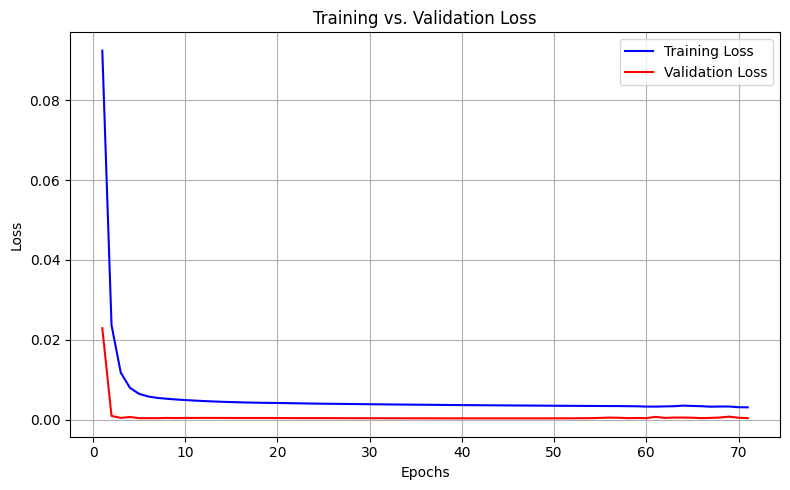

In [68]:
train_loss = model_history.history['loss']
val_loss = model_history.history['val_loss']

epochs = range(1, len(train_loss) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_loss, 'b-', label='Training Loss')
plt.plot(epochs, val_loss, 'r-', label='Validation Loss')
plt.title('Training vs. Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [139]:
import shap
explainer = shap.GradientExplainer(model, x_val)
shap_values = explainer.shap_values(x_val)

C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_50
Received: inputs=['Tensor(shape=(103, 30, 2))']
  warnings.warn(msg)
C:\Users\rajdh\Desktop\ETH_Price_Predition\.venv\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_50
Received: inputs=['Tensor(shape=(50, 30, 2))']
  warnings.warn(msg)


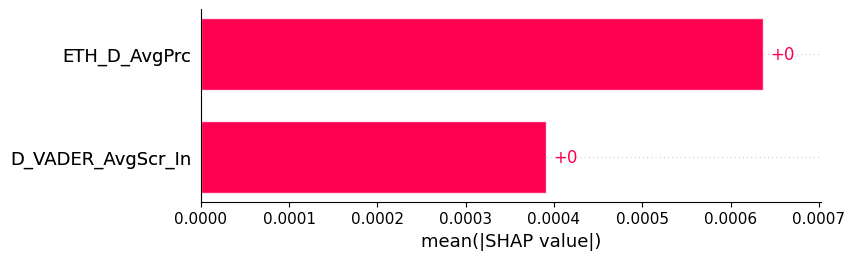

In [140]:
target_class = 0
shap_vals_all_classes = shap_values.mean(axis=-1)
shap_vals_reshaped = shap_vals_all_classes.reshape(-1, shap_values.shape[2])  
x_val_reshaped = x_val.reshape(-1, x_val.shape[2]) 
feature_names = [str(i) for i in range(x_val.shape[2])]
explanation = shap.Explanation(
    values=shap_vals_reshaped,    
    data=x_val_reshaped,
    feature_names=features
)
shap.plots.bar(explanation)

In [25]:
global_mean_per_timestep = shap_values_mean.mean(axis=0)
import matplotlib.pyplot as plt

plt.plot(global_mean_per_timestep)
plt.xlabel("Time Step")
plt.ylabel("Average SHAP Value")
plt.title("Mean SHAP Value per Time Step (Averaged Across Outputs)")
plt.grid()
plt.show()

NameError: name 'shap_values_mean' is not defined

In [26]:
avg_explanation = shap.Explanation(
    values=shap_values.values.mean(axis=2) ,
    base_values=np.mean(shap_values.base_values, axis=1),  # shape: (931,)
    data=shap_values.data,
    feature_names=shap_values.feature_names
)

AttributeError: 'numpy.ndarray' object has no attribute 'values'

In [40]:
mean_shap.shape

(123, 10, 1)

In [27]:
global_importance = np.mean(np.abs(shap_values), axis=0)

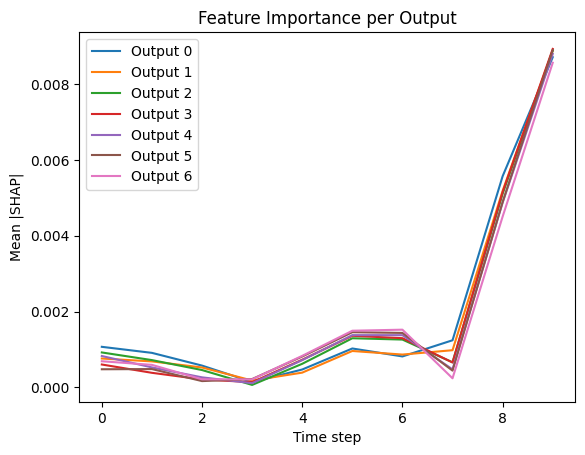

In [28]:
import matplotlib.pyplot as plt

for k in range(shap_values.shape[-1]):
    plt.plot(global_importance[:, 0, k], label=f'Output {k}')
plt.legend()
plt.xlabel("Time step")
plt.ylabel("Mean |SHAP|")
plt.title("Feature Importance per Output")
plt.show()

### Walk-forward sliding window

In [49]:
train, test = DL.split_data(split_size=split_size)
train, val = DL.split_data(split_size=split_size, split_type="train_val", overlap=True, overlap_size=5)
predictions = []
purpose = "train"
split = "validation"
experiment_name = f"BiLSTM_{purpose}_{split}"
mlflow.set_tracking_uri(f"sqlite:///{root_dir}/mlruns/mlruns.db")
mlflow.set_experiment(experiment_name)
with mlflow.start_run(run_name=f"ETH_lag"):
    # mlflow.keras.autolog()
    train_iter = train
    if split.lower() == "validation":
        iterations = len(val) - n_periods - lags +1
        iter_array = val
    elif split.lower() == "test":
        iterations = len(test) - n_periods - lags +1
        iter_array = test
    for t in range(iterations):
        y_train, x_train = DL.generate_X_y_tensors(train_iter, data_split="train", tensor_format="numpy")
        y_val, x_val = DL.generate_X_y_tensors(iter_array, data_split=split, tensor_format="numpy")
        model.fit(x_train, y_train, epochs=50, batch_size=64, verbose=0)
        forecast = model.predict(x_val[0:1])
        predictions.append(forecast.flatten().tolist())
        train_iter = pd.concat([train_iter, iter_array[0:1]], ignore_index=False)
        iter_array = iter_array[1:]
    mse_list = []
    rmse_list = []
    mae_list = []
    mape_list = []
    transposed = np.array(predictions)
    y_scaler, _ = DL.get_scalers()
    y_val, x_val = DL.generate_X_y_tensors(val, data_split=split, tensor_format="numpy")
    for i in range(len(transposed)):
        mse = mean_squared_error(y_scaler.inverse_transform(y_val[:,i].reshape(-1,1)), y_scaler.inverse_transform(transposed[:,i].reshape(-1,1)))
        rmse = root_mean_squared_error(y_scaler.inverse_transform(y_val[:,i].reshape(-1,1)), y_scaler.inverse_transform(transposed[:,i].reshape(-1,1)))
        mae = mean_absolute_error(y_scaler.inverse_transform(y_val[:,i].reshape(-1,1)), y_scaler.inverse_transform(transposed[:,i].reshape(-1,1)))
        mape = mean_absolute_percentage_error(y_scaler.inverse_transform(y_val[:,i].reshape(-1,1)), y_scaler.inverse_transform(transposed[:,i].reshape(-1,1)))
        mse_list.append(mse)
        rmse_list.append(rmse)
        mae_list.append(mae)
        mape_list.append(mape)
        mlflow.log_metrics({"mse_daily":mse_list[i], "rmse_daily":rmse_list[i], "mae_daily":mae_list[i], "mape_daily":mape_list[i]}, step=(i+1))
    avg_mse = sum(mse_list)/len(mse_list)
    avg_rmse = sum(rmse_list)/len(rmse_list)
    avg_mae = sum(mae_list)/len(mae_list)
    avg_mape = sum(mape_list)/len(mape_list)
    mlflow.log_metrics({"avg_mse": avg_mse, "avg_rmse": avg_rmse, "avg_mae": avg_mae, "avg_mape": avg_mape})
mlflow.end_run()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━

ValueError: Found input variables with inconsistent numbers of samples: [133, 7]

In [67]:
rmse_list

[46.5777125556404,
 77.22725048260997,
 100.95877842003554,
 123.84108013042845,
 145.42734484849618,
 170.71889119226694,
 189.82091258392975]

In [141]:
result = model.predict(x_val)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 202ms/step


In [142]:
_,y_scaler = DL.get_scalers()

In [143]:
result_rev = y_scaler.inverse_transform(result)

In [144]:
rmse_daily = []
y_true = y_scaler.inverse_transform(y_val)
for i in range(result_rev.shape[1]):
    rmse = root_mean_squared_error(y_true[:,i], result_rev[:,i])
    rmse_daily.append(rmse)

In [145]:
rmse_daily

[41.00051804202674,
 55.24437763553356,
 68.18001400033661,
 78.55955935094684,
 87.2775809488141,
 95.91533160658443,
 97.83829463594716]

In [78]:
rmse_daily

[29.3987405616717,
 53.966050641414704,
 70.47175660099639,
 82.26009085056143,
 88.9829705170639,
 98.38767386012343,
 103.97364358866122]

In [158]:
result = model.predict(x_test)
result_rev = y_scaler.inverse_transform(result)
rmse_daily = []
y_true = y_scaler.inverse_transform(y_test)
for i in range(result_rev.shape[1]):
    rmse = root_mean_squared_error(y_true[:,i], result_rev[:,i])
    rmse_daily.append(rmse)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


In [159]:
rmse_daily

[33.13259747498835,
 51.48555055082277,
 64.01929667002126,
 73.2159838856719,
 81.89189633572397,
 90.22517887497129,
 98.50544379610115]